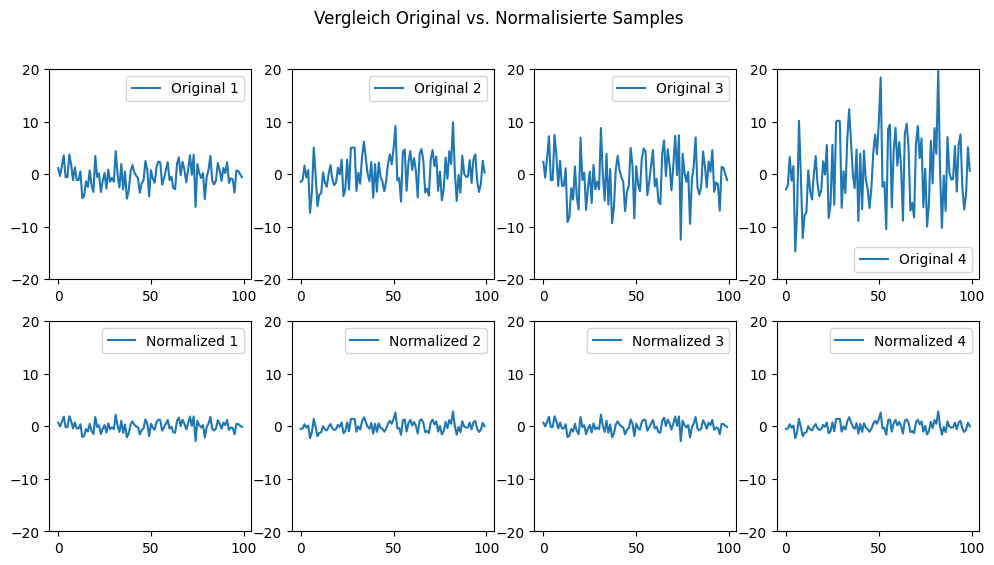

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Beispiel: Erstellen von 5 Samples mit zufälligen Werten (positive und negative)
np.random.seed(42)
num_samples = 4
num_points = 100

# Erstellen von zufälligen Daten mit unterschiedlichen Amplituden
samples = [np.random.randn(num_points) * np.random.uniform(0.5, 5.0) for _ in range(num_samples // 2)]

samples.append(samples[0] * 2)
samples.append(samples[1] * 2)

y_min = -20
y_max = 20


# 1. Lokale Z-Normalisierung pro Sample
normalized_samples = [(sample - np.mean(sample)) / np.std(sample) for sample in samples]

# 2. Globale Skalierung anhand der mittleren Amplitude (Max-Wert pro Sample als Amplitudenmaß)
global_amplitude = np.mean([np.max(np.abs(sample)) for sample in normalized_samples])
scaled_samples = [sample * (global_amplitude / np.max(np.abs(sample))) for sample in normalized_samples]

# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 6))

for i, (orig, norm) in enumerate(zip(samples, scaled_samples)):
    plt.subplot(2, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}", )
    plt.ylim(y_min, y_max)

    plt.legend()
    
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(norm, label=f"Normalized {i+1}")
    plt.ylim(y_min, y_max)
    plt.legend()

plt.suptitle("Vergleich Original vs. Normalisierte Samples")
plt.show()

In [7]:
print(np.mean(samples))

0.05588297248132735


0.05588297248132735
[np.float64(1.7297573266929724), np.float64(3.1600308230387), np.float64(3.459514653385945), np.float64(6.3200616460774)]
0.05588297248132735
[np.float64(30.953208998876196), np.float64(56.54729307920383), np.float64(61.90641799775239), np.float64(113.09458615840767)]


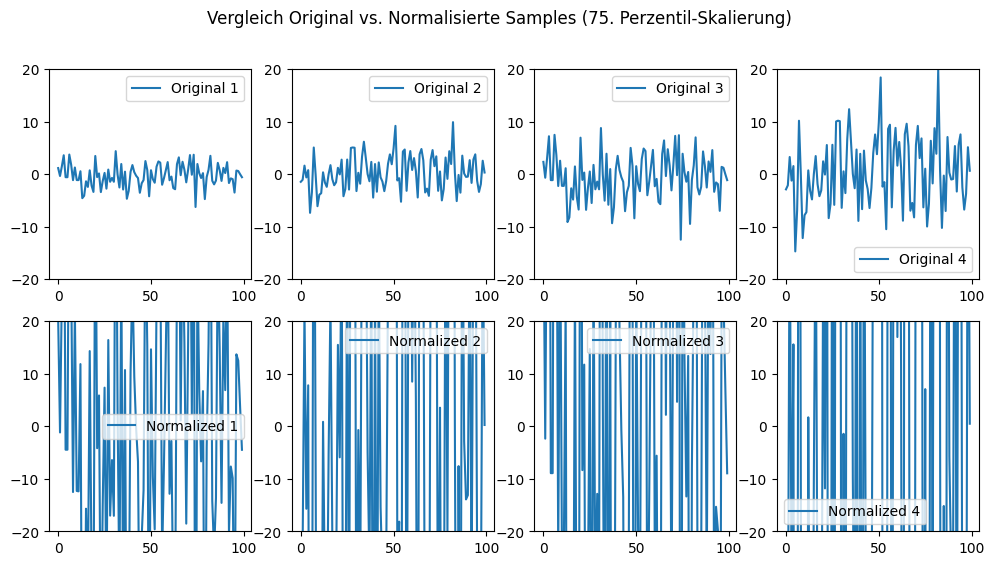

In [ ]:


percentile =60

# 2. Globale Skalierung anhand des 75. Perzentils pro Sample
global_amplitude = np.mean([np.percentile(np.abs(sample), percentile) for sample in samples])
# global_amplitude = np.mean(samples)

print([np.percentile(np.abs(sample), percentile) for sample in samples])
print(global_amplitude)
print([(np.percentile(np.abs(sample), percentile)/global_amplitude) for sample in samples])
scaled_samples = np.array([normalized_samples[s_i] * (np.percentile(np.abs(sample), percentile)/global_amplitude ) for s_i, sample in enumerate(samples)])

# Bestimmen der gemeinsamen y-Limits für eine einheitliche Skalierung


# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 6))

for i, (orig, norm) in enumerate(zip(samples, scaled_samples)):
    plt.subplot(2, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()
    
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(norm, label=f"Normalized {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()

plt.suptitle("Vergleich Original vs. Normalisierte Samples (75. Perzentil-Skalierung)")
plt.show()

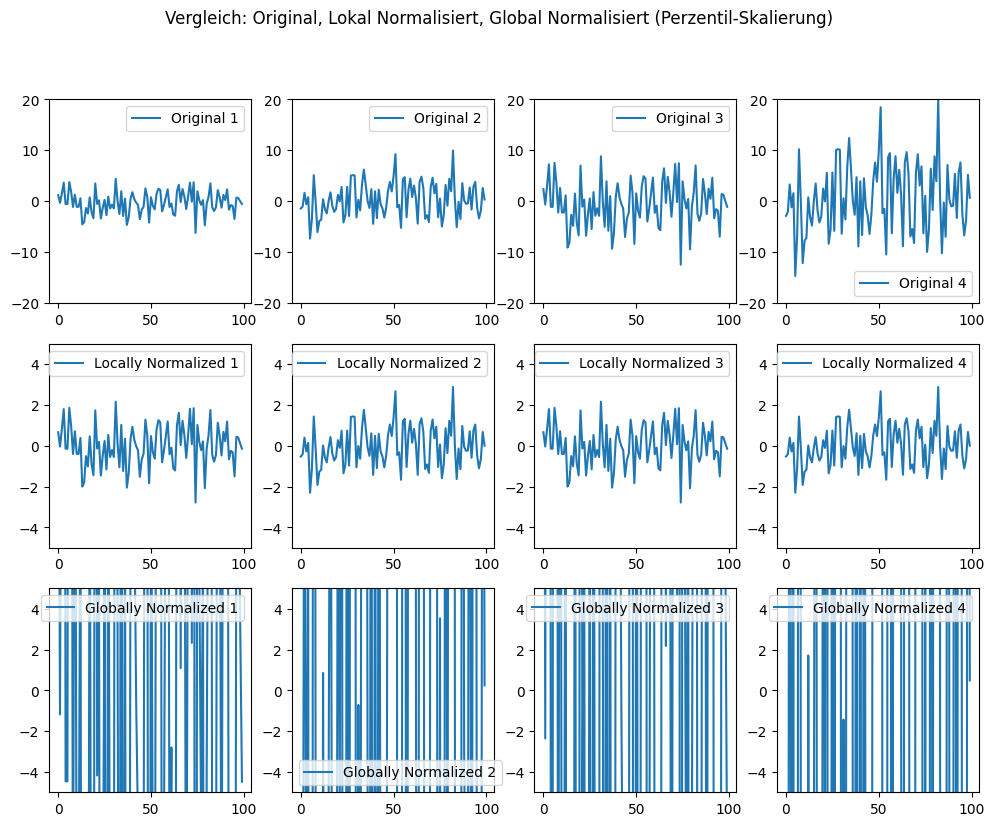

In [5]:
# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 9))

for i, (orig, norm_local, norm_global) in enumerate(zip(samples, normalized_samples, scaled_samples)):
    plt.subplot(3, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()
    
    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.plot(norm_local, label=f"Locally Normalized {i+1}")
    plt.ylim(-5, 5)  # Einheitliche y-Limits setzen
    plt.legend()

    plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
    plt.plot(norm_global, label=f"Globally Normalized {i+1}")
    plt.ylim(-5, 5)  # Einheitliche y-Limits setzen
    plt.legend()

plt.suptitle("Vergleich: Original, Lokal Normalisiert, Global Normalisiert (Perzentil-Skalierung)")
plt.show()
